In [12]:
# ---- Setup & imports ----
import sys
from pathlib import Path

# Make the package importable from this notebook's location
proj_dir = Path('../..').resolve()
if str(proj_dir) not in sys.path:
    sys.path.insert(0, str(proj_dir))

# Auto-reload modules when source files change (no kernel restart needed)
%load_ext autoreload
%autoreload 2

import amfora
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

print(f"amfora loaded from: {amfora.__file__}")
print(f"Version: {amfora.__version__}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
amfora loaded from: /Users/aiacobucci922/Documents/Python/AMFOrA/amfora/__init__.py
Version: 1.0.0


In [13]:
# --- EDIT THESE ---
IMAGE_DIR    = "/Users/aiacobucci922/Documents/Ceramic Project Raw Data/AMFOrA_Test_Bars/prepared"   # folder with multiple sherd scans
SCAN_DPI     = 1200                              # scanner resolution


In [14]:
# full_analysis -- comprehensive batch analysis of all images in a directory
test_bars_full = amfora.full_analysis(IMAGE_DIR, scan_dpi=SCAN_DPI, analyze_core_periphery=True, save_csv=True, output_filename="test_bars_full_analysis.csv")
display(test_bars_full)

Starting full analysis of 150 ceramic sherds...
Using scan DPI: 1200
Detection methods: Blob + Contour
Analyzing inclusions: True
Analyzing voids: True
--------------------------------------------------
Processing R14G_2.jpeg (1/150)
  Success - Blob: 108 inclusions, Contour: 81 inclusions
Processing R04G_2.jpeg (2/150)
  Success - Blob: 34 inclusions, Contour: 33 inclusions
Processing R04TC_2.jpeg (3/150)
  Success - Blob: 37 inclusions, Contour: 41 inclusions
Processing R05TC_2.jpeg (4/150)
  Success - Blob: 87 inclusions, Contour: 75 inclusions
Processing R07G_4.jpeg (5/150)
  Success - Blob: 111 inclusions, Contour: 85 inclusions
Processing R02TC_5.jpeg (6/150)
  Success - Blob: 43 inclusions, Contour: 35 inclusions
Processing R11G_1.jpeg (7/150)
  Success - Blob: 165 inclusions, Contour: 123 inclusions
Processing R01G_1.jpeg (8/150)
  Success - Blob: 4 inclusions, Contour: 3 inclusions
Processing R03TC_5.jpeg (9/150)
  Success - Blob: 63 inclusions, Contour: 52 inclusions
Processi

,filename,file_path,scan_dpi,analysis_status,sherd_area_cm2,blob_inclusion_count,blob_inclusion_total_area_cm2,blob_inclusion_mean_area_cm2,blob_inclusion_std_area_cm2,blob_inclusion_min_area_cm2,...,inner_margin_color_b,outer_margin_color_l,outer_margin_color_a,outer_margin_color_b,core_atmosphere,inner_margin_atmosphere,outer_margin_atmosphere,core_periphery_gradient,firing_interpretation,margin_symmetry
0,R14G_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.556370,108,0.115180,0.001066,0.001467,0.000176,...,134.0,191.0,132.0,135.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,25.019992,incomplete_oxidation,symmetric
1,R04G_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.489421,34,0.037166,0.001093,0.000775,0.000190,...,133.0,207.0,132.0,136.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,16.155494,incomplete_oxidation,symmetric
2,R04TC_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.615783,37,0.031911,0.000862,0.000676,0.000147,...,151.0,137.0,148.0,149.0,oxidized,oxidized,oxidized,6.000000,fully_oxidized,symmetric
3,R05TC_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.561092,87,0.087228,0.001003,0.001703,0.000182,...,149.0,139.0,148.0,148.0,oxidized,oxidized,oxidized,7.141428,fully_oxidized,symmetric
4,R07G_4.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.550393,111,0.047700,0.000430,0.000251,0.000154,...,132.0,139.0,133.0,136.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,77.051931,incomplete_oxidation,symmetric
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,R11G_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.572221,170,0.136676,0.000804,0.001544,0.000147,...,136.0,215.0,131.0,133.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,9.695360,incomplete_oxidation,symmetric
146,R11TC_5.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.499958,88,0.091690,0.001042,0.002033,0.000134,...,148.0,126.0,144.0,146.0,oxidized,oxidized,oxidized,17.029386,fully_oxidized,symmetric
147,R10TC_5.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.521947,76,0.098561,0.001297,0.002080,0.000147,...,149.0,144.0,147.0,148.0,oxidized,oxidized,oxidized,10.246951,fully_oxidized,symmetric
148,R12G_4.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.562176,177,0.200871,0.001135,0.001551,0.000152,...,134.0,214.0,133.0,136.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,12.165525,incomplete_oxidation,symmetric


## User Input

Edit the three variables below to point at your own data.

In [15]:
# --- EDIT THESE ---

SINGLE_IMAGE = "/Users/aiacobucci922/Documents/Ceramic Project Raw Data/AMFOrA_Test_Bars/prepared/R08TC_4.jpeg"         # one sherd scan

SCAN_DPI     = 1200                              # scanner resolution
def imshow_cm(ax, image, dpi=SCAN_DPI, cmap=None, **kwargs):
    """Display image with axes in centimeters."""
    h, w = image.shape[:2]
    extent = [0, w / dpi * 2.54, h / dpi * 2.54, 0]
    ax.imshow(image, extent=extent, cmap=cmap, **kwargs)
    ax.set_xlabel("cm")
    ax.set_ylabel("cm")

def imshow_mm(ax, image, dpi=SCAN_DPI, cmap=None, **kwargs):
    """Display image with axes in millimeters."""
    h, w = image.shape[:2]
    extent = [0, w / dpi * 25.4, h / dpi * 25.4, 0]
    ax.imshow(image, extent=extent, cmap=cmap, **kwargs)
    ax.set_xlabel("mm")
    ax.set_ylabel("mm")

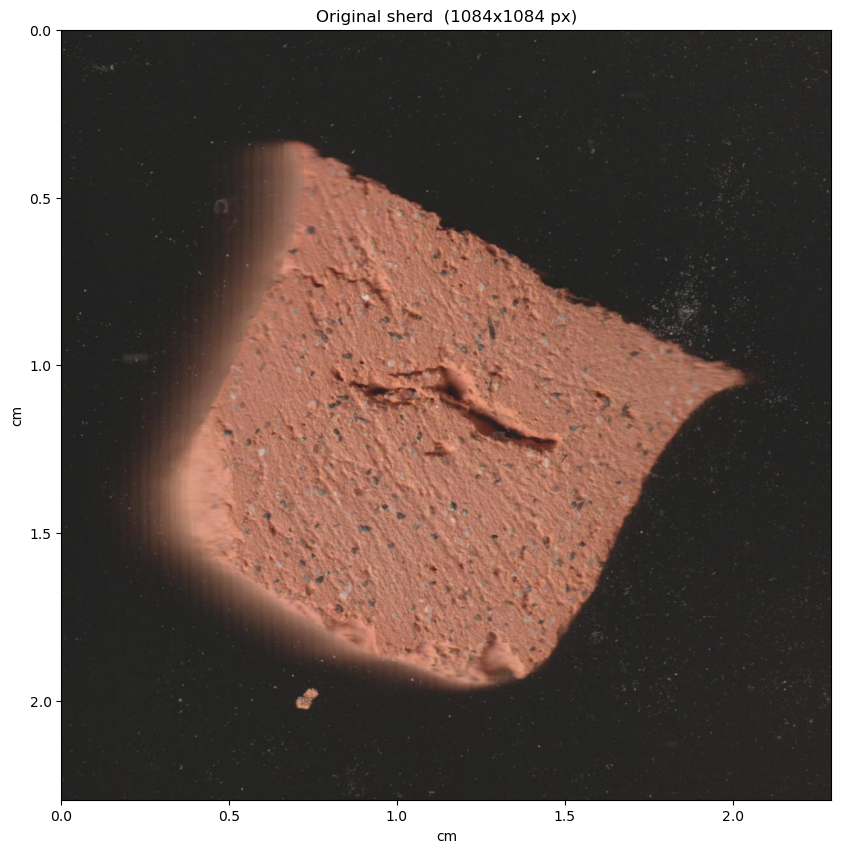

In [16]:
# Load and display the single image
img = cv2.imread(SINGLE_IMAGE)
assert img is not None, f"Could not load image: {SINGLE_IMAGE}"

plt.figure(figsize=(12, 10))
imshow_cm(plt.gca(), img[:, :, ::-1])
plt.title(f"Original sherd  ({img.shape[1]}x{img.shape[0]} px)")
plt.show()

---
## Detection (`core/detection`)

Auto-crop bounds: rows 0:1084, cols 0:1084  (1084 x 1084 px  vs original 1084 x 1084)


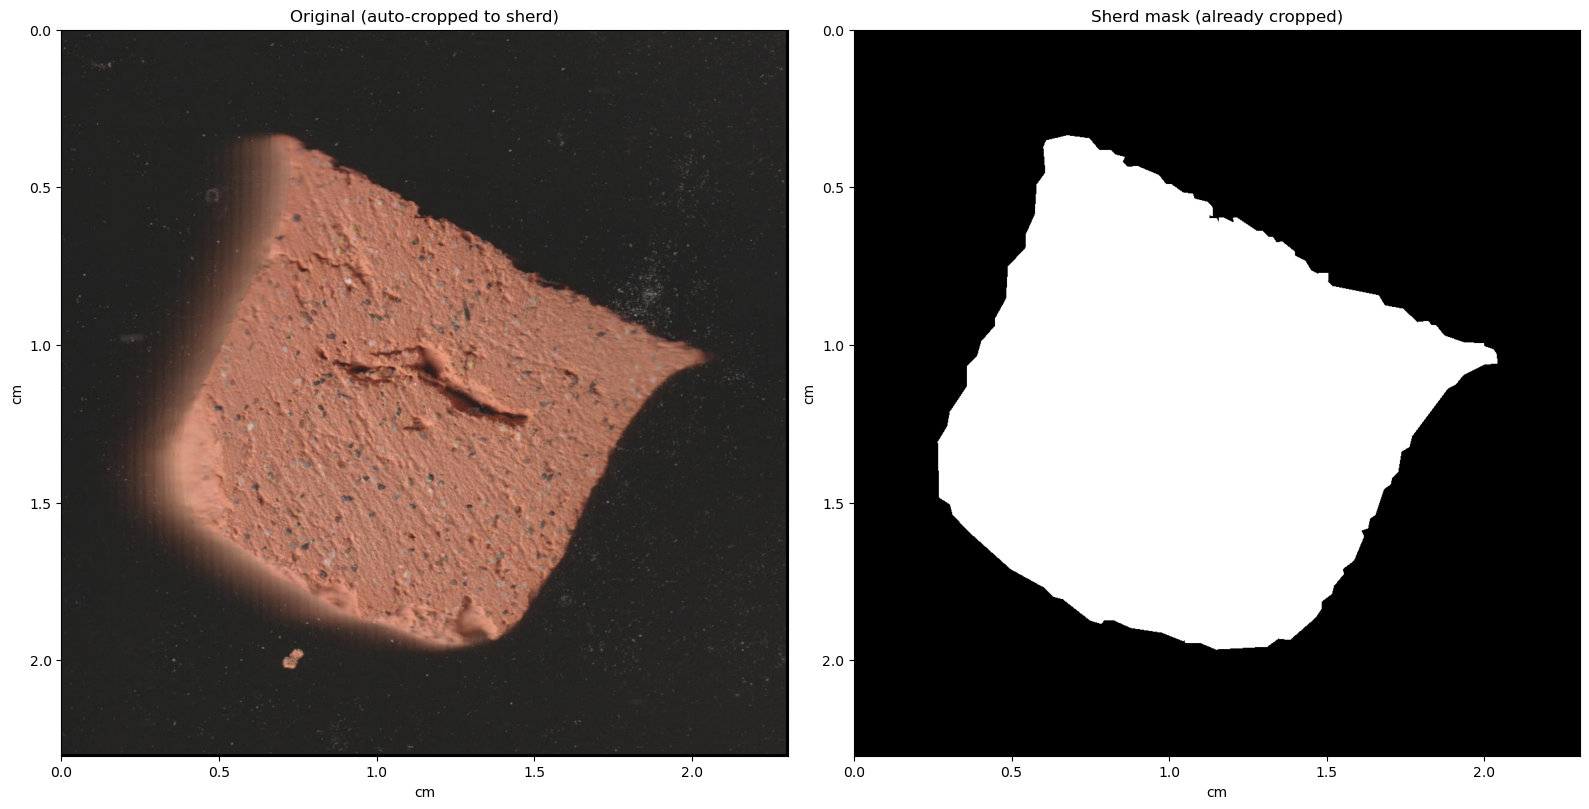

In [17]:
# sherd_mask -- create a binary mask that isolates the sherd from the background
# Returns (mask, crop, sherd_contour) where crop=(y1, y2, x1, x2, pad_top, pad_bottom, pad_left, pad_right)
# in original image coordinates. Extra padding values are >0 when the sherd is near the scan edge.
# The mask is already cropped to the sherd bounding box + 75 px buffer.
# Pass auto_crop=False to get a full-size mask matching the original scan dimensions.
mask, crop, sherd_contour = amfora.sherd_mask(img, scan_dpi=SCAN_DPI)
y1, y2, x1, x2 = crop[:4]
print(f"Auto-crop bounds: rows {y1}:{y2}, cols {x1}:{x2}  "
      f"({y2-y1} x {x2-x1} px  vs original {img.shape[0]} x {img.shape[1]})")

# For display, pad the cropped original to match the (possibly padded) mask dimensions
import numpy as np
_img_crop = img[y1:y2, x1:x2]
if len(crop) == 8:
    _pt, _pb, _pl, _pr = crop[4:]
    if _pt or _pb or _pl or _pr:
        _img_crop = np.pad(_img_crop, ((_pt, _pb), (_pl, _pr), (0, 0)),
                           mode='constant', constant_values=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
imshow_cm(axes[0], _img_crop[:, :, ::-1])
axes[0].set_title("Original (auto-cropped to sherd)")
imshow_cm(axes[1], mask, cmap="gray")
axes[1].set_title("Sherd mask (already cropped)")
plt.tight_layout()
plt.show()

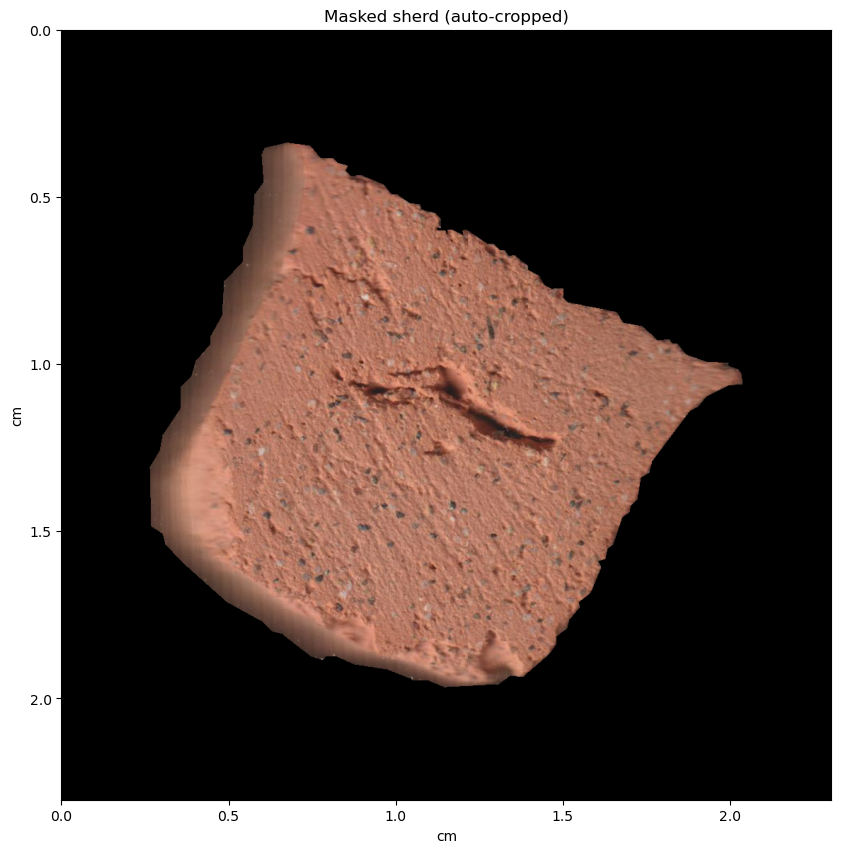

In [18]:
# apply_mask -- crop the original image to the sherd region and apply the mask.
# After this call masked_img is already at the cropped size; no further slicing needed.
masked_img = amfora.apply_mask(img, mask, crop)

plt.figure(figsize=(12, 10))
imshow_cm(plt.gca(), masked_img[:, :, ::-1])
plt.title("Masked sherd (auto-cropped)")
plt.show()


Inclusions detected: 95
Voids detected:      3


Text(0.5, 1.0, 'Inclusions (green): 95  |  Voids (red): 3')

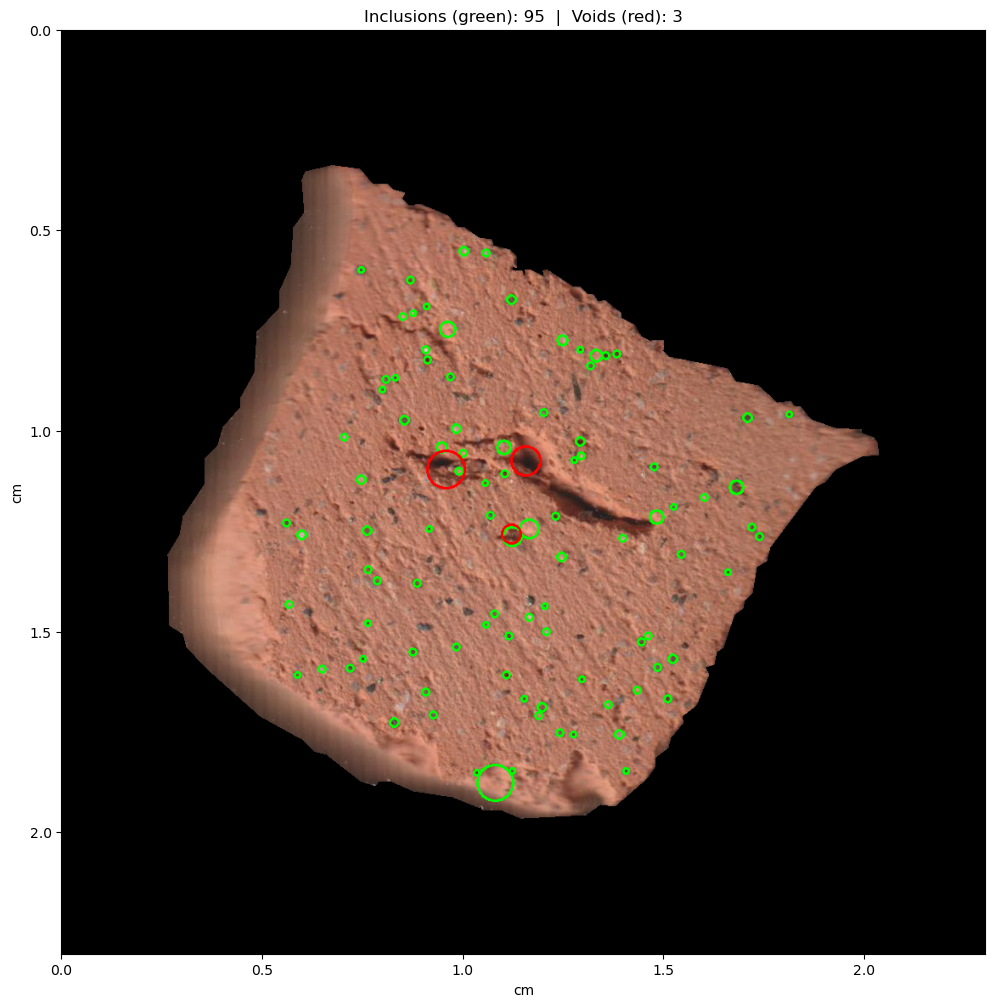

In [19]:
# sherd_blobs -- detect inclusions (light blobs) and voids (dark blobs)
inclusion_blobs, void_blobs = amfora.sherd_blobs(masked_img, scan_dpi=SCAN_DPI)
print(f"Inclusions detected: {len(inclusion_blobs)}")
print(f"Voids detected:      {len(void_blobs)}")

# Overlay blob circles on the masked image
overlay = masked_img.copy()
for kp in inclusion_blobs:
    x, y = map(int, kp.pt)
    r = max(1, int(kp.size / 2))
    cv2.circle(overlay, (x, y), r, (0, 255, 0), 2)
for kp in void_blobs:
    x, y = map(int, kp.pt)
    r = max(1, int(kp.size / 2))
    cv2.circle(overlay, (x, y), r, (0, 0, 255), 2)

plt.figure(figsize=(14, 12))
imshow_cm(plt.gca(), overlay[:, :, ::-1])
plt.title(f"Inclusions (green): {len(inclusion_blobs)}  |  Voids (red): {len(void_blobs)}")

Contour inclusions: 97
Contour voids:      17


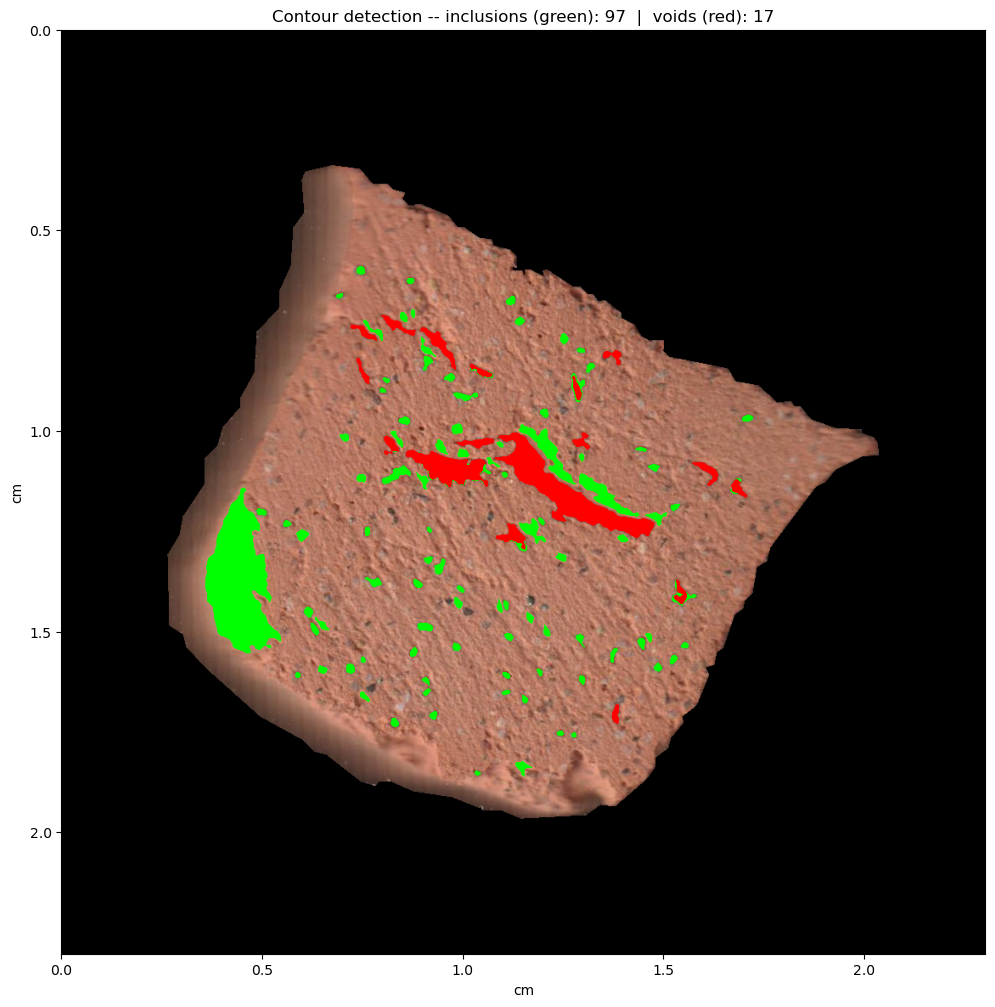

In [20]:
# contour_detection -- contour-based feature detection (better for angular/irregular shapes)
contour_results = amfora.contour_detection(masked_img, scan_dpi=SCAN_DPI)

print(f"Contour inclusions: {contour_results['total_inclusions']}")
print(f"Contour voids:      {contour_results['total_voids']}")

# Draw contours on the masked image
contour_img = masked_img.copy()
cv2.drawContours(contour_img, contour_results['inclusions'], -1, (0, 255, 0), -1)
cv2.drawContours(contour_img, contour_results['voids'], -1, (0, 0, 255), -1)

plt.figure(figsize=(14, 12))
imshow_cm(plt.gca(), contour_img[:, :, ::-1])
plt.title(f"Contour detection -- inclusions (green): {contour_results['total_inclusions']}  |  voids (red): {contour_results['total_voids']}")
plt.show()


In [21]:
test_bars_full.sort_values("contour_inclusion_count", ascending = True, inplace=True)

In [22]:
test_bars_full.head(25)

,filename,file_path,scan_dpi,analysis_status,sherd_area_cm2,blob_inclusion_count,blob_inclusion_total_area_cm2,blob_inclusion_mean_area_cm2,blob_inclusion_std_area_cm2,blob_inclusion_min_area_cm2,...,inner_margin_color_b,outer_margin_color_l,outer_margin_color_a,outer_margin_color_b,core_atmosphere,inner_margin_atmosphere,outer_margin_atmosphere,core_periphery_gradient,firing_interpretation,margin_symmetry
120,R01G_3.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.559497,1,0.000910,0.000910,0.000000,0.000910,...,136.0,220.0,131.0,133.0,oxidized_low_iron,incomplete_oxidation,incomplete_oxidation,13.000000,incomplete_oxidation,symmetric
102,R01G_4.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.521195,5,0.002941,0.000588,0.000716,0.000202,...,134.0,197.0,132.0,136.0,oxidized_low_iron,incomplete_oxidation,incomplete_oxidation,30.133038,mixed_atmosphere,symmetric
112,R01TC_5.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.702969,1,0.001587,0.001587,0.000000,0.001587,...,144.0,128.0,150.0,149.0,oxidized,oxidized,oxidized,29.478806,fully_oxidized,symmetric
23,R01TC_1.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.746625,1,0.001912,0.001912,0.000000,0.001912,...,144.0,128.0,150.0,150.0,oxidized,oxidized,oxidized,34.452866,fully_oxidized,symmetric
81,R01TC_4.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.472136,1,0.000255,0.000255,0.000000,0.000255,...,149.0,138.0,151.0,152.0,oxidized,oxidized,oxidized,14.628739,fully_oxidized,symmetric
7,R01G_1.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.572476,4,0.001565,0.000391,0.000218,0.000186,...,135.0,204.0,132.0,135.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,18.055470,incomplete_oxidation,symmetric
144,R01G_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.524582,7,0.008177,0.001168,0.001996,0.000253,...,133.0,222.0,131.0,134.0,incomplete_oxidation,oxidized_low_iron,incomplete_oxidation,8.124038,incomplete_oxidation,symmetric_transitional
93,R01G_5.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.491598,7,0.008125,0.001161,0.001193,0.000363,...,135.0,218.0,132.0,136.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,6.708204,incomplete_oxidation,symmetric
77,R15TC_3.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.607593,10,0.006192,0.000619,0.000476,0.000187,...,145.0,103.0,143.0,143.0,oxidized,oxidized,oxidized,46.270941,fully_oxidized,symmetric
128,R01TC_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.534577,12,0.012321,0.001027,0.001347,0.000210,...,149.0,136.0,149.0,150.0,oxidized,oxidized,oxidized,7.071068,fully_oxidized,symmetric
